# Pythonによる微分方程式の数値計算

はじめに
　物理現象、生理現象、病気の蔓延や社会現象など様々な現象を微分方程式に表すことができる。しかし、ほとんどの場合、紙と鉛筆では解けない。このような時、コンピュータを用いた数値解析を行う。ここでは、最も一般的に使われているルンゲ＝クッタ法（Runge-Kutta method）を用いてコロナウイルス陽性者のデータを SIR モデルで解析する。第 1 回物理学実験テキスト「統計処理 (最小 2 乗法)」に準拠するので、参考にせよ。初めから難しいことをしても分からないので、簡単な手法およびモデルから始めて、数理解析の専門的な話題まで行く。

# 1　オイラー法によるロジステック方程式の解法


Logistic equation (統計処理 (最小 2 乗法)式 (26))は、フラスコの中の大腸菌の数のような、限られた栄養源の中での生物の繁殖を表す。

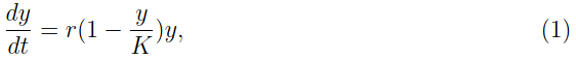

この微分方程式の解は、t=0のとき、y=y0とすると、

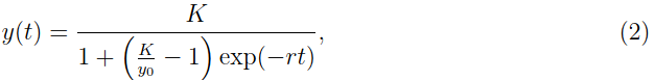

となる。一方で、dtを微小時間とすると、微分の定義から、

$\frac{dy}{dt}(t)=\frac{y(t+dt)-y(t)}{dt}$を代入すると、


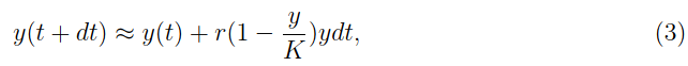

となる。したがって、時刻tにおけるy(t)が分かれば、時刻t+dtにおける近似値を式(3)から求めることができる。このようにして微分方程式の数値解を求める方法をEuler法という。以下に添付したpython codeは、このためのものである。コピーして実行せよ。


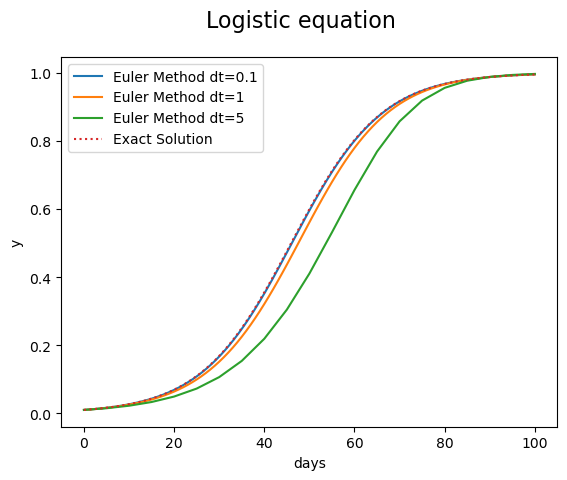

In [1]:
#　Euler法によるロジステック方程式の数値解
import numpy as np                    #数値計算用モジュールを読み込む
import matplotlib.pyplot as plt       #描画用のモジュールを読み込む
from src.diffrentialequations import Logistics #srcフォルダ内のdiffrentialequations.pyの中にあるロジステック方程式クラスを読み込む

tmax=100    
y0=0.01 #初期値
r =0.1
K=1

dt=0.1
time,yexact,yeuler=Logistics(tmax=tmax,dt=dt,y0=y0,r=r,K=K).Euler()

dt2 = 1
time2,yexact2,yeuler2=Logistics(tmax=tmax,dt=dt2,y0=y0,r=r,K=K).Euler()

dt3 = 5
time3,yexact3,yeuler3=Logistics(tmax=tmax,dt=dt3,y0=y0,r=r,K=K).Euler()

plt.style.use('default')             #描画スタイルは通常の形

fig, ax = plt.subplots()
fig.suptitle("Logistic equation", fontsize = 16)
ax.plot(time ,yeuler, label = f"Euler Method dt={dt}")     #描画用データ作成(表示しないがここで図を作成)
ax.plot(time2,yeuler2, label = f"Euler Method dt={dt2}")     
ax.plot(time3,yeuler3, label = f"Euler Method dt={dt3}")     
ax.plot(time,yexact,linestyle="dotted", label = "Exact Solution")  

ax.legend()
ax.set_xlabel("days")             
ax.set_ylabel("y")

plt.show()

解析解とEuler法の両方が図示されるが、dt=0.1ではよく一致しているが、dt=1とすると微妙にずれる。

# 以下にパラメータを変えて実行せよ。

In [ ]:

#　ここにEuler法によるロジステック方程式の数値解をコピーして実行する












## 後退Euler法

$\frac{dy}{dt}(t)=\frac{y(t)-y(t-dt)}{dt}$を代入してみると、

$y(t)=y(t-dt)+dt\, r\left(1-\frac{y(t)}{K}\right)y(t)$となる。

時間を取り直すと、

$y(t+dt)=y(t)+dt\, r\left(1-\frac{y(t+dt)}{K}\right)y(t+dt)$

先程のオイラー法で、$y(t)$と$y(t+dt)$を逆転させたものが得られる。
つまり、未来$y(t+dt)$から現在$y(t)$に向かって$-dt$だけ時間を巻き戻す計算をすることになるので、後退Euler法と呼ばれる。

実際には、未来の値はこれから決めるべき未知の量なので、未来の値が過去の値へ収束する（上の方程式の解となる）ように非線形方程式を反復計算などを用いて解く必要がある。後退Euler法は時間を進めた(実際には戻す向きだが)先の値が確定しているので、数値的な発散がないというメリットがある。硬い微分方程式(stiff equation)の数値解法に用いられる。

ここでは方程式を陽に解いてみる。

後退Euler法の方程式を変形すると、

$\frac{rdt}{K}y^2(t+dt)+(1-rdt)y(t+dt)-y(t)=0$となる。

解くと,

$y(t+dt)=\frac{(rdt-1)+\sqrt{(1-rdt)^2+\frac{4rdt}{K}y(t)}}{2rdt/K}$となる。

$dt\rightarrow0$で, $y(t)\rightarrow y(t-dt)$となる解を採用した。

この場合は、Euler法と同様に逐次的に値を代入し、次の時刻の解を得ることができる。

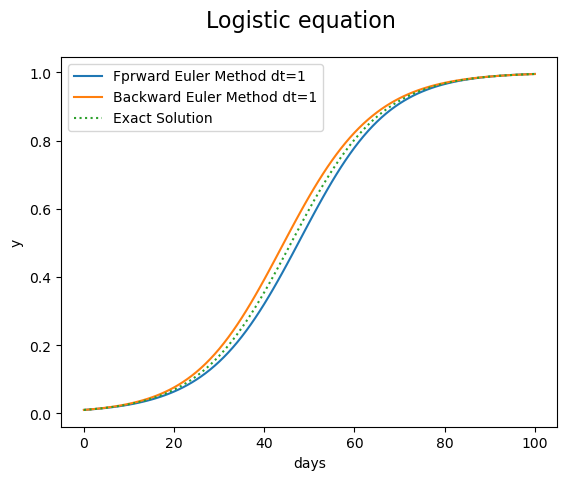

In [ ]:
#　後退Euler法によるロジステック方程式の数値解
import numpy as np                    #数値計算用モジュールを読み込む
import matplotlib.pyplot as plt       #描画用のモジュールを読み込む
from src.diffrentialequations import Logistics #srcフォルダ内のdiffrentialequations.pyの中にあるロジステック方程式クラスを読み込む

tmax=100    
y0=0.01 #初期値
r =0.1
K=1
dt=1

solver=Logistics(tmax=tmax,dt=dt,y0=y0,r=r,K=K) #ロジステック方程式クラスのインスタンスを作成

time,yexact,yeuler=solver.Euler()
time2,yexact2,yeuler2=solver.BackwardEuler()

plt.style.use('default')             #描画スタイルは通常の形

fig, ax = plt.subplots()
fig.suptitle("Logistic equation", fontsize = 16)
ax.plot(time ,yeuler, label = f"Fprward Euler Method dt={dt}")     #描画用データ作成(表示しないがここで図を作成)
ax.plot(time2,yeuler2, label = f"Backward Euler Method dt={dt}")     
ax.plot(time,yexact,linestyle="dotted", label = "Exact Solution")  

ax.legend()
ax.set_xlabel("days")             
ax.set_ylabel("y")

plt.show()

ロジステック方程式の場合は、前進と後退Euler法の選択に意味はない。

# 以下にパラメータを変えて実行せよ。

In [ ]:

#　ここに後退Euler法によるロジステック方程式の数値解をコピーして実行する












# 2 　万有引力の例

重心の静止系における惑星の運動方程式は

$\frac{d^2x}{dt^2}=-GM\frac{x}{(x^2+y^2)^{\frac{3}{2}}}$

$\frac{d^2y}{dt^2}=-GM\frac{y}{(x^2+y^2)^{\frac{3}{2}}}$

である。もしくは、1階の微分方程式系に変換して、

$\frac{dx}{dt}=v_x$

$\frac{dv_x}{dt}=-GM\frac{x}{(x^2+y^2)^{\frac{3}{2}}}$

$\frac{dy}{dt}=v_y$

$\frac{dv_y}{dt}=-GM\frac{y}{(x^2+y^2)^{\frac{3}{2}}}$


軌道長半径$a=$と周期$T=2\pi\sqrt{\frac{a^3}{GM}}$を用いて、時間を$T$で、距離を$a$で無次元化すると、

$\frac{dx}{dt}=v_x$

$\frac{dv_x}{dt}=-4\pi^2\frac{x}{(x^2+y^2)^{\frac{3}{2}}}$

$\frac{dy}{dt}=v_y$

$\frac{dv_y}{dt}=-4\pi^2\frac{y}{(x^2+y^2)^{\frac{3}{2}}}$

これをオイラー法で解く。初期条件は、$x=1, y=0, v_x=0, v_y=2\pi$とする。この場合、解析解は円軌道となる。


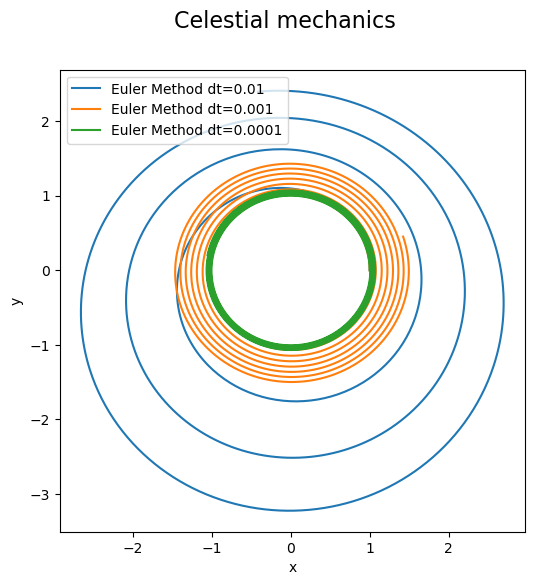

In [9]:
# Euler法による天体運動の数値計算
import numpy as np               
import matplotlib.pyplot as plt       
from src.diffrentialequations import Kepler

x0=np.array([1,0])    #初期位置
v0=np.array([0,2*np.pi])  #初期速度
tmax=10   #計算時間

dt=0.01  #刻み時間
time,x_euler,_=Kepler(dt=dt,tmax=tmax,x0=x0,v0=v0).Euler()

dt2=0.001  #刻み時間
time2,x_euler2,_=Kepler(dt=dt2,tmax=tmax,x0=x0,v0=v0).Euler()

dt3=0.0001  #刻み時間
time3,x_euler3,_=Kepler(dt=dt3,tmax=tmax,x0=x0,v0=v0).Euler()

plt.style.use('default')

fig, ax = plt.subplots(figsize=(6,6))
fig.suptitle("Celestial mechanics", fontsize = 16)

ax.plot(x_euler[:,0],x_euler[:,1], label = f"Euler Method dt={dt}")     
ax.plot(x_euler2[:,0],x_euler2[:,1], label = f"Euler Method dt={dt2}")     
ax.plot(x_euler3[:,0],x_euler3[:,1], label = f"Euler Method dt={dt3}")     

ax.legend()
ax.set_xlabel("x")
ax.set_ylabel("y")
#ax.set_xlim(-10,10)
#ax.set_ylim(-10,10)


plt.show()

どんなに小さい$dt$でも徐々に無限遠に飛び出していくことがわかる。

# 3  Runge-Kutta method

微分方程式の数値解法は無数にあり、用途に応じて適切な手法を選ぶ必要があるが、その中にあって最も汎用性が高く多用されている方法はルンゲ＝クッタ法である:

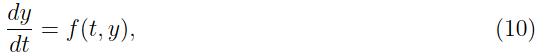

を解くために、以下のような計算をする。時刻tにおけるy(t)を用い、時刻t+hでのy(t+h)は、(慣例なので、dtのかわりにhを用いた。)

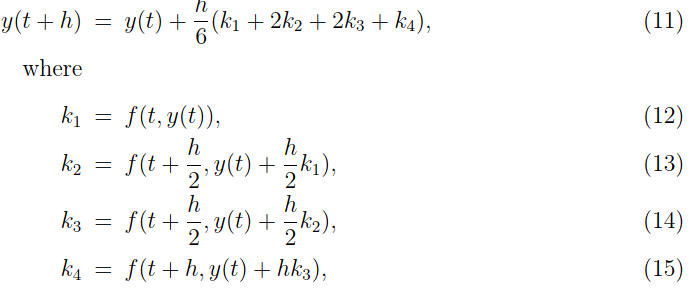

である。変数の数が多い場合(多元)への拡張は容易であり、2元のばあいには、以下のようになる。

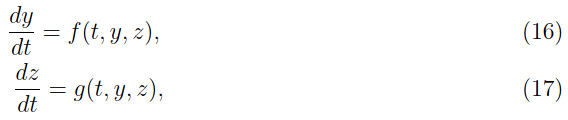

に対する数値解法：

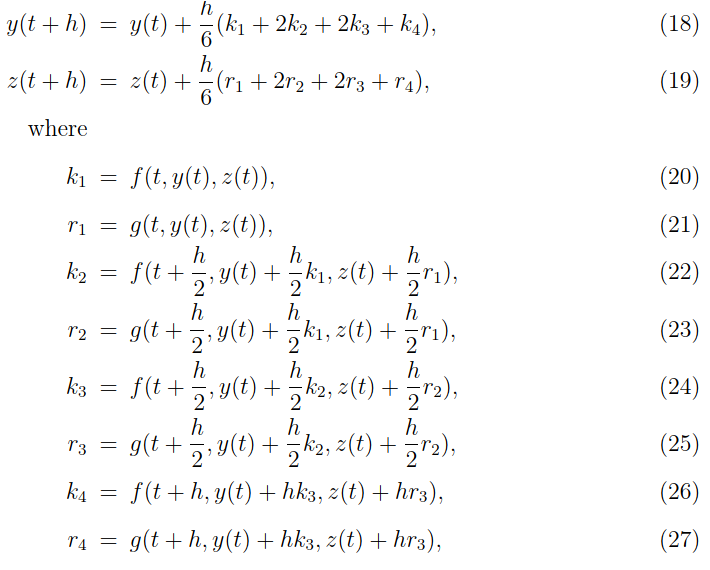


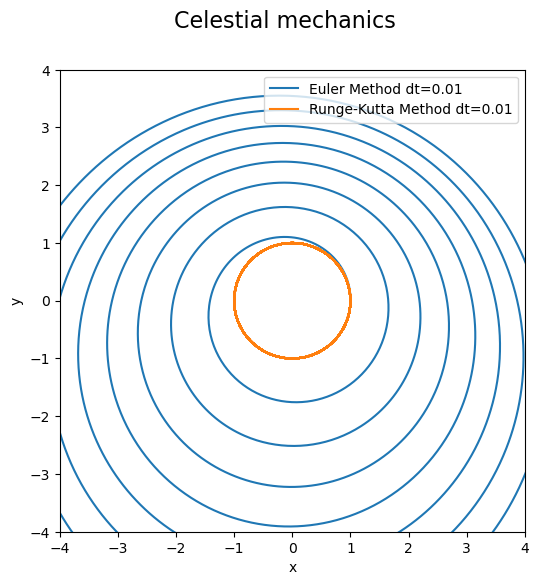

In [ ]:
# Runge-Kutta法による天体運動の数値計算
import numpy as np               
import matplotlib.pyplot as plt       
from src.diffrentialequations import Kepler

x0=np.array([1,0])    #初期位置
v0=np.array([0,2*np.pi])  #初期速度
tmax=50   #計算時間

dt=0.01  #刻み時間
solver=Kepler(dt=dt,tmax=tmax,x0=x0,v0=v0)

time,x_euler,_=solver.Euler()
time,x_rk4,_=solver.RK4()

plt.style.use('default')

fig, ax = plt.subplots(figsize=(6,6))
fig.suptitle("Celestial mechanics", fontsize = 16)

ax.plot(x_euler[:,0],x_euler[:,1], label = f"Euler Method dt={dt}")     
ax.plot(x_rk4[:,0],x_rk4[:,1], label = f"Runge-Kutta Method dt={dt}")     

ax.legend()
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_xlim(-4,4)
ax.set_ylim(-4,4)


plt.show()

この例から数値解法の適切な選択が非常に重要であることが分かると思う。

# 課題: 以下にパラメータを他の軌道でシミュレーションを行え。

In [11]:

#　ここにコピーして実行する












# 5 　SIRモデル

SIRモデルは感染症の蔓延と回復を表す1つの方法である。式(27)-(30)に簡単な説明がある。webにも情報が多いので、検索して調べよ。
未感染者(感受性保持者susceptible)の数をS ,感染者infectedの数をI, 免疫保持者recoveredの数をR,として

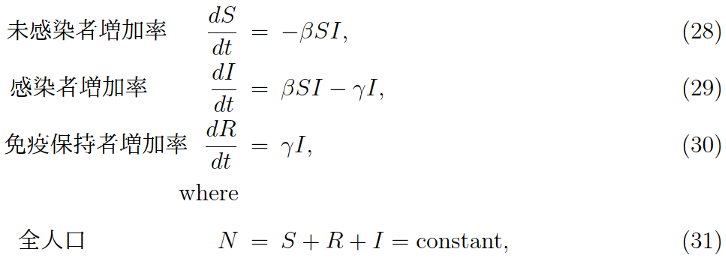

として記述する。γについては、式(29)の最後の項、-γIから、治癒日数と関連していることがわかる。この項だけなら、

$I(t) = I_0 exp(-\gamma t )$　　　　　　　　　　（32）

となるから、1/γは感染した人が治癒して感染者数が1/eに減少する日数を表す。

次にβの意味を考えてみる。式(29)の第1項に注目すると、感染者の増加率に関連していることが分かる。1人あたり毎日平均m人と接触すると仮定すると、そのうち感染している人の割合はI/N  (Nは全人口)であるから、 未感染者が感染者と接触する数は1日あたりm S I/N となる。 1回の接触で感染する確率をpとすれば、1日の間に生じる新たな感染者は、全体としてp m S I/N なので、式(29)第1項と比較して、β=pm/Nである。

## SIRモデルを現実に合わせる

先のSIRモデル計算と東京都が発表したCOVID-19陽性者数のデータを並べて表示するpython codeを以下に示す.報告データの陽性者数は1日あたりなのでIではなくβSIとしている.虫眼鏡をクリックして領域を選び,xをクリックすると,両者が一緒に表示されるが,ただ一緒に表示されるだけで現実に合わせたパラメータにはなっていない未完成プログラムである.


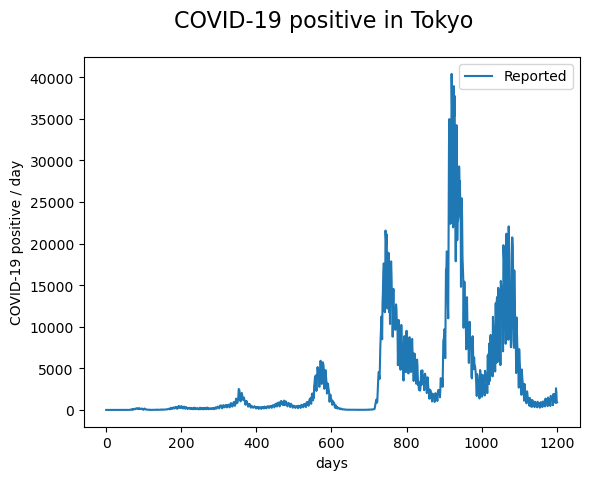

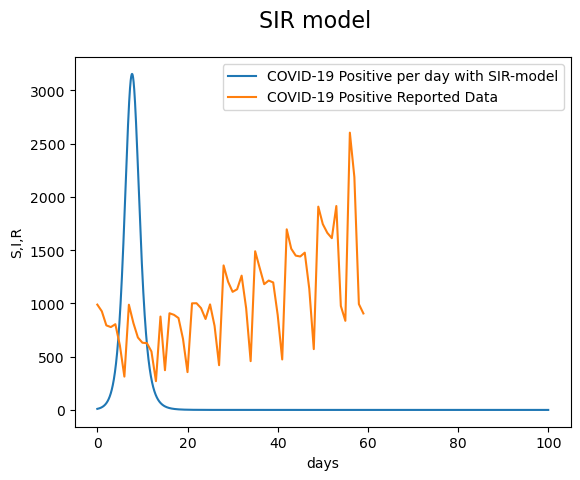

In [25]:
#未完成のプログラムである。各自修正せよ。
# SIRモデルと現実のデータの比較
import numpy as np                  
import matplotlib.pyplot as plt

pathdir ="./"  #各自修正　データファイルの場所
path = pathdir + "data20230505-20200120.txt"   #データファイル名
           #   https://stopcovid19.metro.tokyo.lg.jp/　から引用
with open(path) as fileobj:          
    dlist =  fileobj.readlines()

datalist = dlist[::-1]     
data = [ int(s) for s in  datalist]  #

plt.style.use('default')             #描画スタイルは通常の形

fig, ax = plt.subplots()
fig.suptitle("COVID-19 positive in Tokyo", fontsize = 16)
ax.plot(data, label = "Reported")     #描画用データ作成

ax.legend()
ax.set_xlabel("days")             
ax.set_ylabel("COVID-19 positive / day")            

#plt.savefig(pathdir+"Fig1.pdf")   #図の保存
plt.show()                       #図を表示する

#　×をクリックして図を閉じた後の処理
xmin, xmax = ax.get_xlim()       #選んだ領域の最小、最大
xmin=int(xmin)
xmax=int(xmax)
RepData = data[xmin:xmax] #選んだ領域のデータ

tmax=100        #初期値
dt=0.01     
N0 = 14000    #　人口 1.4万人　東京は1400万人、不適切？
I0 = 10         #　初期感染者 10人
S0 = N0-10       #　未感染者　
R0 =0           #  初期免疫保持者　0
r = 1/14        #  14日程度で治癒する
b = 0.1*10/N0    #  p=0.1, m=10,  感染する確率

t = [ ]      #リストであることを事前に宣言
S = [ ]
I = [ ]
R = [ ]
N = [ ]
bSI=[ ]        #1日あたりの陽性者数

def SIRmodel(S,I,R):
    return -b*S*I, b*S*I-r*I,r*I

def RungeKuttaOneStepForward(S,I,R, dt): 
    s1,i1,r1 =SIRmodel(S,I,R)
    s2,i2,r2 =SIRmodel(S+dt/2*s1, I+dt/2*i1, R+dt/2*r1)
    s3,i3,r3 =SIRmodel(S+dt/2*s2, I+dt/2*i2, R+dt/2*r2)
    s4,i4,r4 =SIRmodel(S+dt  *s3, I+dt  *i3, R + dt*r3)
    return (s1+2*s2+2*s3+s4)*dt/6 + S, (i1+2*i2+2*i3+i4)*dt/6 + I,  (r1+2*r2+2*r3+r4)*dt/6 + R

tprev=0
Sprev=S0 
Iprev=I0
Rprev=R0

while tprev < tmax :
    S.append(Sprev)
    I.append(Iprev)
    R.append(Rprev)
    t.append(tprev)
    N.append(Sprev+Iprev+Rprev)
    bSI.append(b*Sprev*Iprev)
    Sprev,Iprev,Rprev = RungeKuttaOneStepForward(Sprev, Iprev,Rprev, dt)
    tprev += dt
    

plt.style.use('default')             #描画スタイルは通常の形

fig, ax2 = plt.subplots()
fig.suptitle("SIR model", fontsize = 16)
#ax.plot(t,S, label = "S: susceptible")    
#ax.plot(t,I, label = "I: infected")  
#ax.plot(t,R, label = "R: recovered")    
#ax.plot(t,N, label = "N: Total population")   

ax2.plot(t,bSI, label = "COVID-19 Positive per day with SIR-model")  
ax2.plot(RepData, label = "COVID-19 Positive Reported Data")  

ax2.legend()
ax2.set_xlabel("days")             
ax2.set_ylabel("S,I,R")            

plt.show()                       #図を表示する


2.）「6 　SIRモデルを現実に合わせる」で示したpython codeは不完全であり使いにくいだけでなく、現実に合っていない。SIRモデルの改良も含めてcodeを修正し、できる範囲でよいので、現実に合うようにしてみよ（難しいので無理をしないこと）。また、感染症の蔓延について考察せよ。